Faber-Jackson Relation plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Firstly, we define the different columns from the data file. We are given the Mass and velocity dispersion. Mass and luminosity are proportional so for the plot we have to log the Mass to depict a representation of Absolute Magnitude. 

In [2]:
skiprow, catid, type, sigma_re, mstar = np.loadtxt('cleaned_data.txt', unpack=True) # Data saved as array in text file
yvalues = np.log(sigma_re)
xvalues = -2.5 * np.log10(mstar) + 5 * np.log10(70) + 25 # Convert star mass to absolute magnitude. star mass is proportional to luminosity, and absolute magnitude is proportional to luminosity. The constant term is the distance modulus for 70 Mpc.

Now we add a linear fit.

In [3]:
M = xvalues
sigma = yvalues

a,b= np.polyfit(M, sigma, 1) # Fit a linear regression to the data
xcoords = np.linspace(np.min(M), np.max(M), 100) # Create an array of x values for the linear regression line
ycoords = a * xcoords + b # Calculate the y values of the linear regression line

Now we have to plot our data in a graph.

Separate by type.

In [4]:
E = type == 0.0
E_S0 = type == 0.5
S0 = type == 1.0
S0_late = type == 1.5

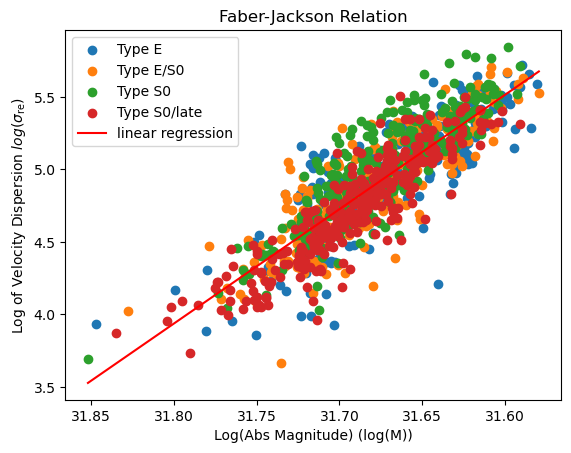

In [5]:
# plt.scatter(xvalues, yvalues, color="black", label="data points") #show data points as black dots

# rewrite for different types

plt.scatter(xvalues[E], yvalues[E], label="Type E")
plt.scatter(xvalues[E_S0], yvalues[E_S0], label="Type E/S0")
plt.scatter(xvalues[S0], yvalues[S0], label="Type S0")
plt.scatter(xvalues[S0_late], yvalues[S0_late], label="Type S0/late")
plt.plot(xcoords, ycoords, color="red", label="linear regression") #show linear regression as red line


plt.gca().invert_xaxis() #invert x axis to match the convention of absolute magnitude (brighter objects have lower magnitudes)

plt.legend(loc="best")
plt.title("Faber-Jackson Relation")
plt.xlabel("Log(Abs Magnitude) (log(M))")
plt.ylabel("Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")
plt.show()

In [6]:
from scipy.optimize import curve_fit

def relation(Mag, k, b):
    return k * Mag + b

params, covariance = curve_fit(relation, M, sigma)

k = params[0] 

fit = relation(M,k,b)

SS_res = np.sum((sigma - fit)**2)
SS_tot = np.sum((sigma - np.mean(sigma))**2)

R2 = 1- SS_res/SS_tot

corr_coef = np.sqrt(R2)

print("k =", k)
print("R^2 =", R2)
print("r=", corr_coef)
print("SS_res=", SS_res)
print("SS_tot=", SS_tot)


k = -7.877639955120639
R^2 = 0.7391125509250553
r= 0.8597165526643391
SS_res= 42.83649706109422
SS_tot= 164.19531569258686


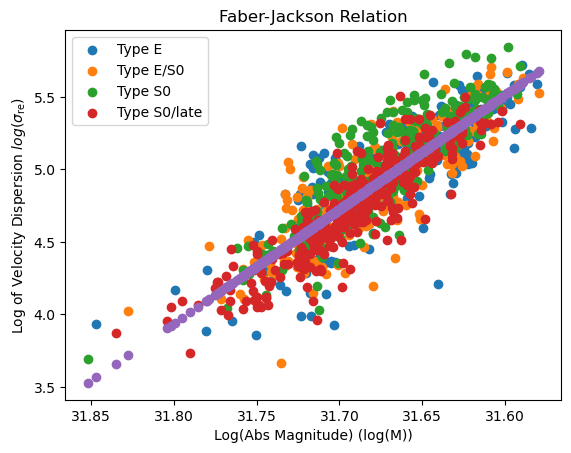

In [7]:
plt.scatter(xvalues[E], yvalues[E], label="Type E")
plt.scatter(xvalues[E_S0], yvalues[E_S0], label="Type E/S0")
plt.scatter(xvalues[S0], yvalues[S0], label="Type S0")
plt.scatter(xvalues[S0_late], yvalues[S0_late], label="Type S0/late")


plt.gca().invert_xaxis() #invert x axis to match the convention of absolute magnitude (brighter objects have lower magnitudes)

plt.legend(loc="best")
plt.title("Faber-Jackson Relation")
plt.xlabel("Log(Abs Magnitude) (log(M))")
plt.ylabel("Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")
plt.scatter(M, fit)
plt.show()


Text(0, 0.5, '$\\Delta$ Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$')

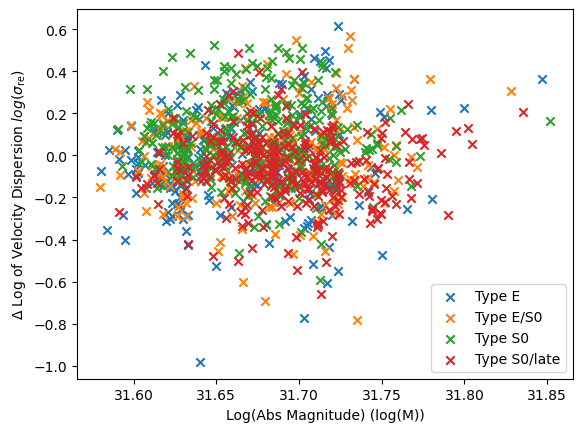

In [8]:
# finding the residuals at each point -> I think we can put this under the curve to show how each point varies

res = sigma - fit

plt.scatter(M[E], res[E], label="Type E", marker = 'x')
plt.scatter(M[E_S0], res[E_S0], label="Type E/S0", marker = 'x')
plt.scatter(M[S0], res[S0], label="Type S0", marker = 'x')
plt.scatter(M[S0_late], res[S0_late], label="Type S0/late", marker = 'x')
plt.legend()


plt.xlabel("Log(Abs Magnitude) (log(M))")
plt.ylabel("$\Delta$ Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")

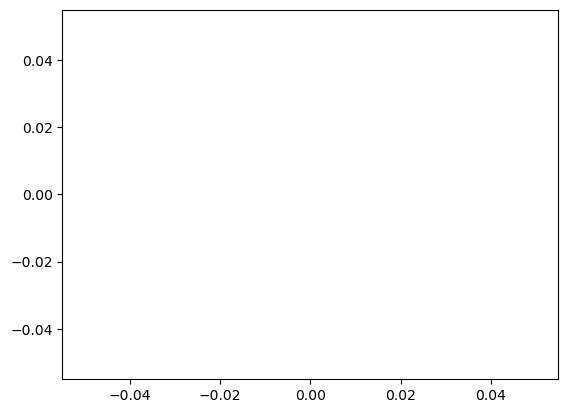

In [9]:
# I think maybe we could add a plot for other galaxies to show it doesnt fit the same pattern


plt.scatter(M[type == 2], res[type == 2], label="Type 2")
plt.scatter(M[type == 2.5], res[type == 2.5], label="Type 2.5")
plt.scatter(M[type == 3], res[type == 3], label="Type 3")

Before, we had a look at the proportional relations between Mass (mstar) and Luminosity. To see if our plot actually fits the proportional relation of 4v we can add the specific conversion of Mass to Luminosity.

The dataset also provides m_r which represents the absolute magnitude of a galaxy in the rest-frame r-band, derived from spectral energy distribution (SED) fits, according to SAMI-documentation. That means that we can simply use x=m_r for our plot.

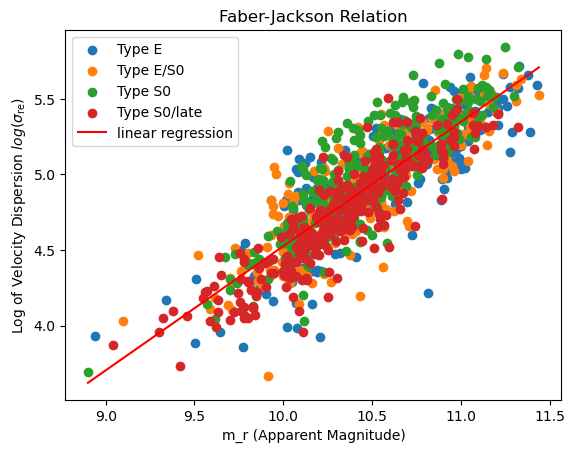

In [11]:
skiprow, catid, type, sigma_re, m_r = np.loadtxt('cleaned_data_mr.txt', unpack=True) # Data saved as array in text file
yvalues = np.log(sigma_re)

xvalues = m_r
sigma = yvalues

a,b= np.polyfit(xvalues, sigma, 1) # Fit a linear regression to the data
xcoords = np.linspace(np.min(xvalues), np.max(xvalues), 100) # Create an array of x values for the linear regression line
ycoords = a * xcoords + b # Calculate the y values of the linear regression line

#Again we seperate by type

E = type == 0.0
E_S0 = type == 0.5
S0 = type == 1.0
S0_late = type == 1.5

#And plot our data points and linear regression line

plt.scatter(xvalues[E], yvalues[E], label="Type E")
plt.scatter(xvalues[E_S0], yvalues[E_S0], label="Type E/S0")
plt.scatter(xvalues[S0], yvalues[S0], label="Type S0")
plt.scatter(xvalues[S0_late], yvalues[S0_late], label="Type S0/late")
plt.plot(xcoords, ycoords, color="red", label="linear regression") #show linear regression as red line


#plt.gca().invert_xaxis() inversion of x axis not necessary anymore

plt.legend(loc="best")
plt.title("Faber-Jackson Relation")
plt.xlabel("m_r (Apparent Magnitude)")
plt.ylabel("Log of Velocity Dispersion $log(\\sigma_{\\text{re}})$")
plt.show()
